# Pytorch Github Repository

[https://github.com/pytorch/pytorch/tree/main/torch](https://github.com/pytorch/pytorch/tree/main/torch)

## torch.nn

In [ ]:
# torch.nn.init.py
import torch
import torch.nn as nn
from torch.nn.init import calculate_gain, _calculate_fan_in_and_fan_out

non_linearity = 'relu'
print(f"Gain of {non_linearity}: {calculate_gain(nonlinearity=non_linearity)}") # sqrt(2)

# fan_in & fan_out은 receptive field x dimension으로 구함
layer = nn.Conv2d(10, 20, kernel_size=3, stride=1, padding=1)
print(layer.weight.data.shape)
fan_in, fan_out = _calculate_fan_in_and_fan_out(layer.weight.data)
print(f"Fan_in: {fan_in} = (3x3)x10 / Fan_out: {fan_out} = (3x3)x20")



Gain of relu: 1.4142135623730951
torch.Size([20, 10, 3, 3])
Fan_in: 90 = (3x3)x10 / Fan_out: 180 = (3x3)x20


## torch.nn.modules

Case 1: inplace=False (out-of-place)

```python
act = nn.ReLU(inplace=False)
y = act(x)

[내부 동작]
- t = act(x)    # 새로운 Tensor 생성
- y = t
```

[특징]
- 입력 x는 변경되지 않음
- 중간 결과를 위한 추가 메모리(t)가 필요함


Case 2: inplace=True (in-place)


```python
act = nn.ReLU(inplace=True)
y = act(x)

[내부 동작]
- x = act(x)    # 입력 Tensor를 직접 수정
- y = x
```

[특징]
- 입력 x 자체가 변경됨
- 추가 메모리 사용 없음
- autograd 사용 시 주의 필요

In [ ]:
import torch.nn as nn
from collections import OrderedDict

# OrderedDict로 넣으면 이름 설정가능
# 그냥 넣으면 차례대로 정수 인덱스
seq_args = nn.Sequential(
    nn.Linear(3, 4),
    nn.BatchNorm2d(4),
    nn.Linear(4, 5),
)

ord_dict = OrderedDict({
    'linear1': nn.Linear(3, 4),
    'bn1': nn.BatchNorm2d(4),
    'linear2': nn.Linear(4, 5),
})
seq_ord = nn.Sequential(ord_dict)

print("====== List of nn.Sequential(*args) =====")
for name, module in seq_args.named_children():
    print(name, ":", module)

print("====== List of nn.Sequential(OrderedDict) =====")
for name, module in seq_ord.named_children():
    print(name, ":", module)


print("\n===== Getting Item by its name =====")
print(seq_args[1])
print(seq_ord.bn1)

print("---")
print(seq_args._modules['1'])
print(seq_ord._modules['bn1'])



====== List of nn.Sequential(*args) =====
0 : Linear(in_features=3, out_features=4, bias=True)
1 : BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
2 : Linear(in_features=4, out_features=5, bias=True)
====== List of nn.Sequential(OrderedDict) =====
linear1 : Linear(in_features=3, out_features=4, bias=True)
bn1 : BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
linear2 : Linear(in_features=4, out_features=5, bias=True)

===== Getting Item by its name =====
BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
---
BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [ ]:
print("\n===== Delete Layers=====")

del seq_args[1]
print(seq_args)
print('---')

del seq_ord[1:3]
print(seq_ord)

print("del을 수행하면 모듈의 이름이 자동적으로 인덱스로 재설정되는거 조심")

# pop, insert 등등 다 똑같음.
# 단, 레이어 추가는 add_module을 통해서 할 수 있음
seq_ord.add_module('bn1', nn.BatchNorm2d(4))
print(seq_ord)



===== Delete Layers=====
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): Linear(in_features=4, out_features=5, bias=True)
)
---
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
)
del을 수행하면 모듈의 이름이 자동적으로 인덱스로 재설정되는거 조심
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (bn1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [ ]:
print("===== Getting the Length =====")
print(len(seq_args))

print("===== Getting the Length of multiple Sequential=====")

seq_multiple = nn.Sequential(
    seq_args, seq_ord
)

print(seq_multiple)
print(len(seq_multiple)) # 그냥 하부 모듈이 몇개있는지만 나오게됨 (3이 출력되어야 하는데 2개 출력)

total = sum(1 for module in seq_multiple.modules() if not isinstance(module, nn.Sequential))
print(f"Total modules: {total}")




===== Getting the Length =====
2
===== Getting the Length of multiple Sequential=====
Sequential(
  (0): Sequential(
    (0): Linear(in_features=3, out_features=4, bias=True)
    (1): Linear(in_features=4, out_features=5, bias=True)
  )
  (1): Sequential(
    (0): Linear(in_features=3, out_features=4, bias=True)
    (bn1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)
2
Total modules: 4


In [ ]:
def show(tag, seq):
    print(f"\n=== {tag} ===")
    print(seq)
    print("len(seq) =", len(seq))

a = nn.Sequential(nn.Linear(3, 4), nn.ReLU(), nn.Linear(4, 5))
b = nn.Sequential(nn.Linear(3, 4), nn.Tanh(), nn.Linear(4, 5))

# +, +=
show("a + b", a + b)
a2 = nn.Sequential(nn.Linear(3, 4), nn.ReLU(), nn.Linear(4, 5))
a2 += b
show("a2 += b", a2)

# pop
p = nn.Sequential(nn.Linear(3, 4), nn.ReLU(), nn.Linear(4, 5))
show("p(before pop)", p)
x = p.pop(1)
print("popped =", x)
show("p(after pop)", p)


=== a + b ===
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=5, bias=True)
  (3): Linear(in_features=3, out_features=4, bias=True)
  (4): Tanh()
  (5): Linear(in_features=4, out_features=5, bias=True)
)
len(seq) = 6

=== a2 += b ===
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=5, bias=True)
  (3): Linear(in_features=3, out_features=4, bias=True)
  (4): Tanh()
  (5): Linear(in_features=4, out_features=5, bias=True)
)
len(seq) = 6

=== p(before pop) ===
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=5, bias=True)
)
len(seq) = 3
popped = ReLU()

=== p(after pop) ===
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): Linear(in_features=4, out_features=5, bias=True)
)
len(seq) = 2


In [ ]:
# *, *=
show("a * 2", a * 2)
m = nn.Sequential(nn.Linear(3, 4), nn.ReLU(), nn.Linear(4, 5))
m *= 3
show("m *= 3", m)


# append, insert, extend
ap = nn.Sequential(nn.Linear(3, 4), nn.ReLU(), nn.Linear(4, 5))
ap.append(nn.Sigmoid())
show("append(Sigmoid)", ap)

ins = nn.Sequential(nn.Linear(3, 4), nn.ReLU(), nn.Linear(4, 5))
ins.insert(1, nn.Sigmoid())
show("insert(1, Sigmoid)", ins)

ext = nn.Sequential(nn.Linear(3, 4), nn.ReLU(), nn.Linear(4, 5))
ext.extend(nn.Sequential(nn.Sigmoid(), nn.Identity()))
show("extend([Sigmoid, Identity])", ext)


=== a * 2 ===
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=5, bias=True)
  (3): Linear(in_features=3, out_features=4, bias=True)
  (4): ReLU()
  (5): Linear(in_features=4, out_features=5, bias=True)
)
len(seq) = 6

=== m *= 3 ===
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=5, bias=True)
  (3): Linear(in_features=3, out_features=4, bias=True)
  (4): ReLU()
  (5): Linear(in_features=4, out_features=5, bias=True)
  (6): Linear(in_features=3, out_features=4, bias=True)
  (7): ReLU()
  (8): Linear(in_features=4, out_features=5, bias=True)
)
len(seq) = 9

=== append(Sigmoid) ===
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=5, bias=True)
  (3): Sigmoid()
)
len(seq) = 4

=== insert(1, Sigmoid) ===
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=

In [ ]:
class ModuleA(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(3, 4)

    def forward(self, x):
        return self.linear1(x)




x = torch.rand(2, 10, 3)
module_a = ModuleA()
print(module_a(x).shape)

module_a.add_module('linear2', nn.Linear(4, 5))
print(module_a)
print(module_a(x).shape)


torch.Size([2, 10, 4])
ModuleA(
  (linear1): Linear(in_features=3, out_features=4, bias=True)
  (linear2): Linear(in_features=4, out_features=5, bias=True)
)
torch.Size([2, 10, 4])


In [ ]:
class ModuleB(nn.Module):
    def __init__(self):
        super().__init__()

        self.a = nn.Sequential(
            nn.Linear(3, 4),
            nn.BatchNorm2d(4)
        )

        self.b = nn.Sequential(
            nn.Linear(3, 4),
            nn.BatchNorm2d(4)
        )

        self.apply(self._print_module)

    def _print_module(self, module):
        print(type(module).__name__)

module_b = ModuleB()

Linear
BatchNorm2d
Sequential
Linear
BatchNorm2d
Sequential
ModuleB


In [ ]:
for name, module in module_b.named_modules():
    if isinstance(module, nn.BatchNorm2d):
        print(module)

print("="*40 + "\n")
for name, p in module_b.named_parameters():
    if 'weight' in name:
        print(name)
        p.requires_grad_(False)

BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

a.0.weight
a.1.weight
b.0.weight
b.1.weight


In [ ]:
torch.save(module_b.state_dict(), "ckpt.pt")

ckpt = torch.load("ckpt.pt", map_location='cpu')

model = ModuleB()
model.load_state_dict(ckpt)
print(model)

Linear
BatchNorm2d
Sequential
Linear
BatchNorm2d
Sequential
ModuleB
ModuleB(
  (a): Sequential(
    (0): Linear(in_features=3, out_features=4, bias=True)
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (b): Sequential(
    (0): Linear(in_features=3, out_features=4, bias=True)
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)


## torch.optim

In [ ]:
"""
parameters can one of below

ParamsT: TypeAlias = (
    Iterable[torch.Tensor]
    | Iterable[dict[str, Any]]
    | Iterable[tuple[str, torch.Tensor]]
)

"""

for module in model.parameters():
    print(module)


# 'params'말고 다른거로 하면 param_groups 접근할떄 오류 생김
param_list = [
    {'params': model.a.parameters(), 'lr': 1e-2},
    {'params': model.b.parameters(), 'lr': 1e-3},
]

print("===== Approaching the optimizer's parameters =====")
sgd = torch.optim.SGD(param_list)

for module in sgd.param_groups:
    print(module['params'])

Parameter containing:
tensor([[-0.3792,  0.3792, -0.2284],
        [ 0.1268,  0.0488,  0.1936],
        [-0.4070, -0.1321, -0.3407],
        [ 0.1766,  0.3176, -0.3920]], requires_grad=True)
Parameter containing:
tensor([ 0.2263, -0.0465,  0.3068, -0.4324], requires_grad=True)
Parameter containing:
tensor([1., 1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)
Parameter containing:
tensor([[ 0.5372,  0.2986,  0.5071],
        [-0.1398, -0.3730, -0.2456],
        [-0.4086, -0.2194,  0.2545],
        [-0.1378,  0.0802,  0.5073]], requires_grad=True)
Parameter containing:
tensor([0.5006, 0.1511, 0.2240, 0.1793], requires_grad=True)
Parameter containing:
tensor([1., 1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)
===== Approaching the optimizer's parameters =====
[Parameter containing:
tensor([[-0.3792,  0.3792, -0.2284],
        [ 0.1268,  0.0488,  0.1936],
        [-0.4070, -0.1321, -0.34

In [ ]:
for i, g in enumerate(sgd.param_groups):
    for p in g['params']:
        if p.requires_grad == True:
            print(p)


print("===== Getting Learning Rate =====")
for p in sgd.param_groups:
    print(f"LR: {p['lr']}")

Parameter containing:
tensor([[-0.3792,  0.3792, -0.2284],
        [ 0.1268,  0.0488,  0.1936],
        [-0.4070, -0.1321, -0.3407],
        [ 0.1766,  0.3176, -0.3920]], requires_grad=True)
Parameter containing:
tensor([ 0.2263, -0.0465,  0.3068, -0.4324], requires_grad=True)
Parameter containing:
tensor([1., 1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)
Parameter containing:
tensor([[ 0.5372,  0.2986,  0.5071],
        [-0.1398, -0.3730, -0.2456],
        [-0.4086, -0.2194,  0.2545],
        [-0.1378,  0.0802,  0.5073]], requires_grad=True)
Parameter containing:
tensor([0.5006, 0.1511, 0.2240, 0.1793], requires_grad=True)
Parameter containing:
tensor([1., 1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)
===== Getting Learning Rate =====
LR: 0.01
LR: 0.001


# torch.utils.data

[https://github.com/pytorch/pytorch/tree/main/torch/utils/data](https://github.com/pytorch/pytorch/tree/main/torch/utils/data)

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomAffine(degrees=(0,10),translate=(0.1,0.2),scale=(0.5,1.2)),
    transforms.ToTensor()])

transform_test = transforms.Compose([
    transforms.ToTensor()])


class SubsetWithTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.classes = subset.dataset.classes

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

In [ ]:
train_ds = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True)
test_ds = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform_test)

train_len = int(0.8 * len(train_ds))
val_len = len(train_ds) - train_len
train_ds, val_ds = random_split(train_ds, [train_len, val_len])

train_ds = SubsetWithTransform(train_ds, transform=transform_train)
val_ds = SubsetWithTransform(val_ds, transform=transform_test)

print(f"Length: Train-{len(train_ds)}, Validation-{len(val_ds)}, Test-{len(test_ds)}")
print(train_ds.classes)

Length: Train-40000, Validation-10000, Test-10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


torch.Size([3, 32, 32])


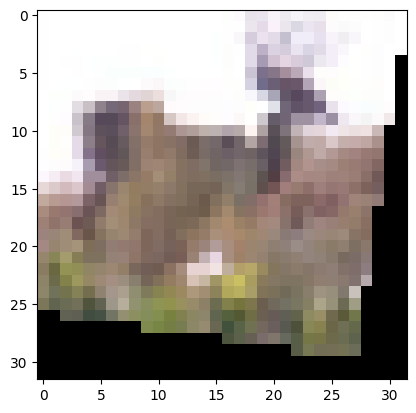

In [ ]:
import matplotlib.pyplot as plt

x, y = train_ds[101]
print(x.shape)
plt.imshow(x.permute(1,2,0))

torch.Size([3, 32, 32])


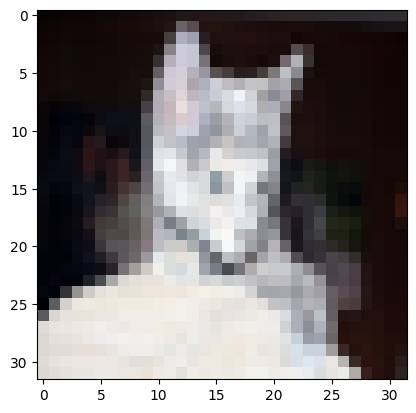

In [ ]:
x, y = val_ds[101]
print(x.shape)
plt.imshow(x.permute(1,2,0))

torch.Size([64, 3, 32, 32]) torch.Size([64])
tensor(4)


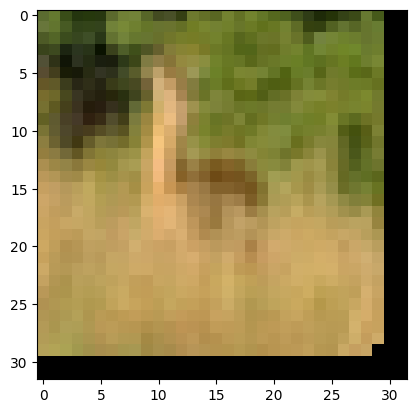

In [ ]:
import torch
def custom_collate_fn(batch):
    data = torch.stack([item[0] for item in batch])
    target = torch.tensor([item[1] for item in batch], dtype=torch.long)

    return {
        'data': data,
        'target': target
    }

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=custom_collate_fn)

batch = next(iter(train_dl))
x_batch, y_batch = batch['data'], batch['target']
print(x_batch.shape, y_batch.shape)
print(y_batch[0])
plt.imshow(x_batch[0].permute(1,2,0))

torch.Size([64, 3, 32, 32]) torch.Size([64])
tensor(3)


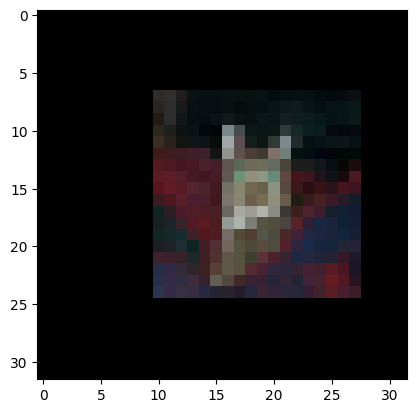

In [ ]:
from torch.utils.data._utils.collate import default_collate

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=default_collate)

batch = next(iter(train_dl))
x_batch, y_batch = batch[0], batch[1] # 인덱스로 접근 (list여서)
print(x_batch.shape, y_batch.shape)
print(y_batch[0])
plt.imshow(x_batch[0].permute(1,2,0))

## torch.distributed

- [DP vs DDP](https://analytics4everything.tistory.com/283)
- [GIL in Python](https://tibetsandfox.tistory.com/43)

In [ ]:
import os
import torch
import torch.distributed as dist
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp

from torch.nn.parallel import DistributedDataParallel as DDP


def setup(rank, world_size):
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"

    # initialize the process group
    dist.init_process_group("nccl", rank=rank, world_size=world_size)


def cleanup():
    dist.destroy_process_group()


class ToyModel(nn.Module):
    def __init__(self):
        super(ToyModel, self).__init__()
        self.net1 = nn.Linear(10, 10)
        self.relu = nn.ReLU()
        self.net2 = nn.Linear(10, 5)

    def forward(self, x):
        return self.net2(self.relu(self.net1(x)))


def train(rank, world_size):
    print(f"Running basic DDP example on rank {rank}.")
    setup(rank, world_size)

    # create model and move it to GPU with id rank
    model = ToyModel().to(rank)
    ddp_model = DDP(model, device_ids=[rank])

    loss_fn = nn.MSELoss()
    optimizer = optim.SGD(ddp_model.parameters(), lr=0.001)

    optimizer.zero_grad()
    outputs = ddp_model(torch.randn(20, 10))
    labels = torch.randn(20, 5).to(rank)
    loss_fn(outputs, labels).backward()
    optimizer.step()

    cleanup()
    print(f"Finished running basic DDP example on rank {rank}.")


if __name__ == "__main__":
    world_size = torch.cuda.device_count()
    mp.spawn(train, args=(world_size,), nprocs=world_size, join=True)

In [ ]:
import os
import torch
import torch.distributed as dist
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp

from torch.nn.parallel import DistributedDataParallel as DDP


def setup():
    # torchrun으로 실행하기에 환경변수에서 가져와야함
    rank = int(os.environ["RANK"])
    world_size = int(os.environ["WORLD_SIZE"])
    local_rank = int(os.environ["LOCAL_RANK"])

    dist.init_process_group("nccl", rank=rank, world_size=world_size)

    return rank, world_size, local_rank


def cleanup():
    dist.destroy_process_group()


class ToyModel(nn.Module):
    def __init__(self):
        super(ToyModel, self).__init__()
        self.net1 = nn.Linear(10, 10)
        self.relu = nn.ReLU()
        self.net2 = nn.Linear(10, 5)

    def forward(self, x):
        return self.net2(self.relu(self.net1(x)))


def train():

    rank, world_size, local_rank = setup()
    print(f"Running DDP example on rank {rank} (local_rank {local_rank}).")

    # 모델을 `local_rank`에 해당하는 GPU로 이동
    model = ToyModel().to(local_rank)
    ddp_model = DDP(model, device_ids=[local_rank])

    loss_fn = nn.MSELoss()
    optimizer = optim.SGD(ddp_model.parameters(), lr=0.001)

    optimizer.zero_grad()
    outputs = ddp_model(torch.randn(20, 10).to(local_rank))  # GPU로 이동
    labels = torch.randn(20, 5).to(local_rank)
    loss_fn(outputs, labels).backward()
    optimizer.step()

    cleanup()
    print(f"Finished running DDP example on rank {rank}.")


if __name__ == "__main__":
    train()

In [ ]:
import os
import torch
import torch.distributed as dist
import torch.nn as nn
import torch.optim as optim
from torch.nn.parallel import DistributedDataParallel as DDP

def setup():
    """ Initialize process group for DDP """
    rank = int(os.environ["RANK"])  # Global Rank
    world_size = int(os.environ["WORLD_SIZE"])  # Total number of processes
    local_rank = int(os.environ["LOCAL_RANK"])  # Local GPU ID for this process

    os.environ["MASTER_ADDR"] = os.environ.get("MASTER_ADDR", "localhost")
    os.environ["MASTER_PORT"] = os.environ.get("MASTER_PORT", "12355")

    # DDP 초기화
    dist.init_process_group("nccl", rank=rank, world_size=world_size)
    return rank, world_size, local_rank

def cleanup():
    """ Destroy process group """
    dist.destroy_process_group()

class ToyModel(nn.Module):
    def __init__(self):
        super(ToyModel, self).__init__()
        self.net1 = nn.Linear(10, 10)
        self.relu = nn.ReLU()
        self.net2 = nn.Linear(10, 5)

    def forward(self, x):
        return self.net2(self.relu(self.net1(x)))

def train():
    rank, world_size, local_rank = setup()
    print(f"Running DDP training on rank {rank} (local_rank {local_rank})")

    # 모델 생성 및 DDP 적용
    model = ToyModel().to(local_rank)
    ddp_model = DDP(model, device_ids=[local_rank])

    loss_fn = nn.MSELoss()
    optimizer = optim.SGD(ddp_model.parameters(), lr=0.001)

    if rank == 0:
        torch.save(ddp_model.state_dict(), "checkpoint.pth")
        print("Model saved at checkpoint.pth")

    dist.barrier()  # Rank 0이 저장을 끝낼 때까지 다른 프로세스는 대기
    map_location = f"cuda:{local_rank}"
    state_dict = torch.load("checkpoint.pth", map_location=map_location)
    ddp_model.load_state_dict(state_dict)
    print(f"Rank {rank}: Model loaded successfully!")

    cleanup()

if __name__ == "__main__":
    train()